# **Detecção de fraudes bancárias, utilizando técnicas de Machine Learning**

## **Solução de negócio**

#### criação de um modelo preditivo capaz de identificar fraudes de maneira eficaz, aplicando técnicas que lidem com a raridade do evento e maximizem a performance do algoritmo, principalmente a métrica Recall, responsável por mostrar o percentual de detecção dos reais casos de fraude, em uma base altamente desbalanceada e anonimizada via PCA.

## **Bibliotecas**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import(
    train_test_split, 
    cross_val_score, 
    StratifiedKFold
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import(
    classification_report, 
    accuracy_score, 
    roc_auc_score, 
    f1_score, 
    precision_recall_curve, 
    confusion_matrix,
    RocCurveDisplay,
    precision_score,
    recall_score,
    average_precision_score
)
from xgboost import XGBClassifier
import shap

c:\Users\rikrd\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **Base de dados**

In [2]:
base = pd.read_csv("../base/CREDIT_CARD_FRAUDE.csv")

df = base.copy()
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
dup = df.duplicated().sum()
duplicatas = df[df.duplicated()]
balanceamento = (df['Class'].value_counts(normalize=True)*100).map('{:.2f}%'.format)
print(f'a base possui {dup} registros duplicados.\n')
print('Percentual de fraudes da base inteira:')
print(balanceamento)
print('\nPercentual de fraudes nos registros duplicados:')
print((duplicatas['Class'].value_counts(normalize=True)*100).map('{:.2f} %'.format))

a base possui 1081 registros duplicados.

Percentual de fraudes da base inteira:
Class
0    99.83%
1     0.17%
Name: proportion, dtype: object

Percentual de fraudes nos registros duplicados:
Class
0    98.24 %
1     1.76 %
Name: proportion, dtype: object


#### o dataset possui 284.807 registros e 31 variáveis numéricas.

#### não há valores nulos, mas há 1081 registros duplicados, representando ~0.4% da base.

#### a decisão técnica de não remover esses registros é pelo risco de prejudicar o modelo e reduzir ainda mais os casos de fraude que já são raros.

#### além disso, esse número de 1.7%, mais que 0.17% da base inteira, sugere que fraudes tendem a repetir padrões e que a técnica do PCA tenha capturado isso como pontos idênticos, com essas duplicatas representando um sinal e não um ruído.

## **Análise do balanceamento do target**

Percentual de cada classe: 

   Class proportion
0      0     99.83%
1      1      0.17%


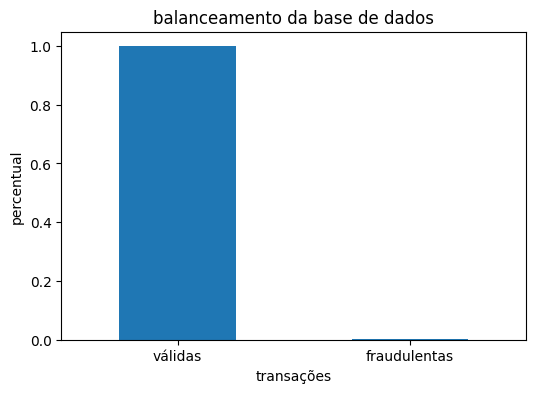

In [5]:
print('Percentual de cada classe: \n')
print((df['Class'].value_counts(normalize=True)*100).map('{:.2f}%'.format).reset_index())

df['Class'].value_counts(normalize=True).plot(kind='bar', figsize=(6,4))
plt.title('balanceamento da base de dados')
plt.ylabel('percentual')
plt.xlabel('transações')
plt.xticks([0, 1], ['válidas', 'fraudulentas'])
plt.xticks(rotation=0)
#plt.savefig('../imagens/balanceamento.png')
plt.show()

In [6]:
casos_fraude = df[df['Class'] == 1]

print(f'Quantidade de fraudes na base de dados: {casos_fraude.shape[0]}')

Quantidade de fraudes na base de dados: 492


#### no dataset há 492 registros de fraude em um total de 284.807, representando ~0.17% da base, indicando que o algoritmo precise de múltiplas técnicas que penalizem mais os erros da classe minoritária.

## **Correlação das variáveis independentes com target**

In [7]:
corr = df.corr()
linear_corr = corr['Class']

linear_corr.sort_values(ascending=True).head(5).reset_index()

,index,Class
0,V17,-0.326481
1,V14,-0.302544
2,V12,-0.260593
3,V10,-0.216883
4,V16,-0.196539


#### o target apresenta correlações inversas moderadas, onde quanto menor o valor maior chance de fraude e as correlações positivas, mesmo fracas podem indicar comportamento suspeito em outra direção

#### valores baixos de correlação são esperados pois o PCA dilui o significado original, além de que há relações não lineares entre as features, apontando que para uma melhor performance, seja melhor um modelo baseado em árvore.

#### analisando a correlação linear com o target, é possível que o modelo performe bem, pois há sinais forte na base.

## **Pré Modelagem**

#### **Separação das bases**

In [8]:
# base X sem a variável target
X = base.drop('Class', axis=1)

# base y com a variável target
y= base['Class']

#### **Divisão da base em treino, validação e teste**

In [9]:
# divisão das bases em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# divisão das bases de treino em sub-treino e validação
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

### **Treino do baseline com técnica cross validation**

In [10]:
# instanciando o modelo simples
model_dtc = DecisionTreeClassifier(max_depth=9,random_state=42, class_weight='balanced')

#configurando
cv = StratifiedKFold(
    n_splits=5,             # núm. de treinos
    shuffle=True,           # embaralha os dados
    random_state=42            # garante reprodutibilidade
)

scores = cross_val_score(
    model_dtc,
    X_tr,
    y_tr,
    scoring='average_precision',
    cv=cv
)

print(f'Resultado em cada subtreino {scores}')
print(f'métrica pr_auc média: {scores.mean():.2f}')
print(f'desvio padrão do resultado: {scores.std():.4f}')

Resultado em cada subtreino [0.46538048 0.51771925 0.49470774 0.63298999 0.57459001]
métrica pr_auc média: 0.54
desvio padrão do resultado: 0.0599


#### A técnica cross validation é mais robusta pois treina o modelo em algumas sub amostras da base de treino, sendo possível avaliar se o modelo performou bem, mesmo 'embaralhando' os dados.

#### E os resultados do treino inicial mostram a qualidade da detecção da classe positiva, apresentando uma métrica auc_pr média de 0.54, que indica mediana capacidade do modelo em detectar fraude, mesmo utilizando o parâmetro: 'class_weight=balanced' que força o modelo a se importar também com a classe minoritária.

#### os resultados em cada treino variaram de ~0.46 a ~0.63, e um desvio padrão de 0.05.

#### na etapa seguinte será avaliada a performance do modelo simples em dados não vistos, ajudando a compreender melhor a complexidade do problema de negócio.

### **Validação do baseline**

pr_auc: 0.54

roc_auc: 0.91

Relatório de classificação:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     39804
           1       0.34      0.83      0.48        69

    accuracy                           1.00     39873
   macro avg       0.67      0.91      0.74     39873
weighted avg       1.00      1.00      1.00     39873




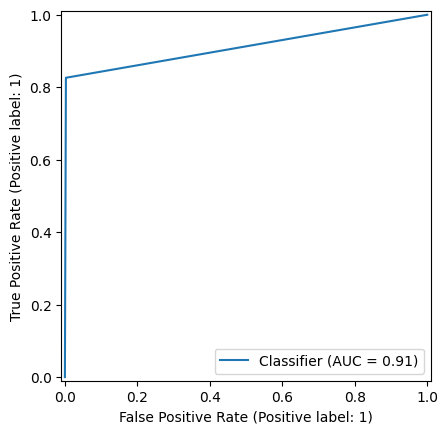

In [11]:
#treino final
model_dtc.fit(X_tr, y_tr)

# teste na base de validação
y_pred1 = model_dtc.predict(X_val)
y_proba1 = model_dtc.predict_proba(X_val)[:,1]

pr_auc_baseline = average_precision_score(y_val, y_proba1)
roc_auc_baseline = roc_auc_score(y_val, y_proba1)

print(f'pr_auc: {pr_auc_baseline:.2f}\n')
print(f'roc_auc: {roc_auc_baseline:.2f}\n')
print(f'Relatório de classificação:\n {classification_report(y_val, y_pred1)}\n')
print(RocCurveDisplay.from_predictions(y_val, y_pred1))
#plt.show()

#### o primeiro modelo manteve a boa performance geral nos novos dados de validação, mas com alguns pontos de atenção:

#### a acurácia de 100% é enganosa, pois é puxada pelos acertos em prever a classe majoritária, enquanto a classe minoritária apresenta um auc_pr de 0.54 e uma média harmônica f1 de 0.48, mostra que existe um trade-off em que o modelo está sensível e pouco conservador. 

#### contudo, na métrica mais importante: recall, que mostra a capacidade do modelo em acertar os casos reais de fraude, o modelo já apresenta um ótimo resultado de 0.83, acertando cerca de 83% dos casos reais de fraude.

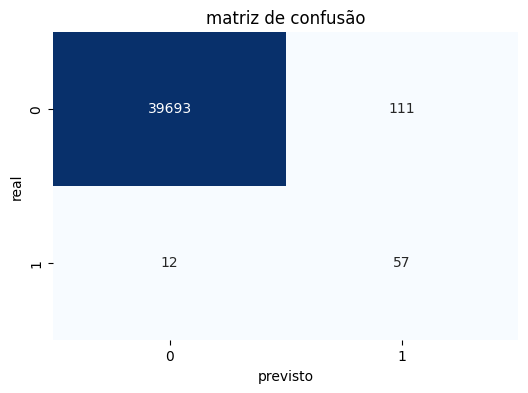

In [12]:
cm = confusion_matrix(y_val, y_pred1)

tb_cm = pd.DataFrame(cm)

fn_baseline = tb_cm.loc[1, 0]
fp_baseline = tb_cm.loc[0, 1]

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)
plt.title('matriz de confusão')
plt.xlabel('previsto')
plt.ylabel('real')
plt.show()

#### o modelo acertou 57 dos 69 casos de fraude (83% de recall), e somente 12 falsos negativos. 

#### mas para esse resultado, o modelo aponta muitos registros como fraude, errando sendo pouco preciso, com 34% de precisão.

#### essa performance é ótima em cenários de fraude, onde é melhor errar e bloquear transação legítima do que deixar fraude passar.

#### mas nas próximas etapas, serão analisadas a aplicação de ajustes no algoritmo, buscando uma melhor harmonia entre sua precision e recall.

### **Análise de trade-off - precision vs recall**

In [13]:
# criando uma lista com os cortes que queremos testar
thresholds = [0.4, 0.5, 0.6]

# 3. O Loop de busca
relatorio_threshold = []

for t in thresholds:
    # Se a proba for maior que o corte, vira 1, senão 0
    predicao = (y_proba1 >= t).astype(int)
    
    # calculando as métricas para este corte específico
    p = precision_score(y_val, predicao)
    r = recall_score(y_val, predicao)
    f1 = f1_score(y_val, predicao)
    
    relatorio_threshold.append({
        'threshold': t,
        'precision': p,
        'recall': r,
        'f1_score': f1
    })

# 4. Transformamos em DataFrame para análise visual
df_busca = pd.DataFrame(relatorio_threshold)
display(df_busca)

,threshold,precision,recall,f1_score
0,0.4,0.339286,0.826087,0.481013
1,0.5,0.339286,0.826087,0.481013
2,0.6,0.339286,0.826087,0.481013


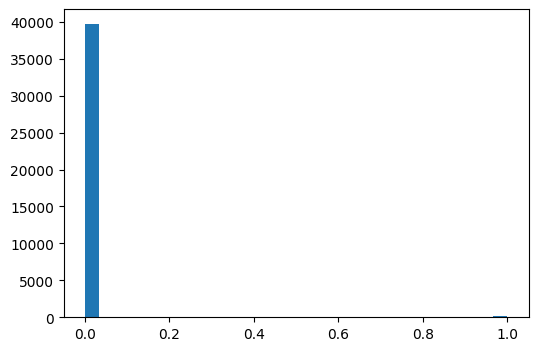

In [14]:
pd.Series(y_proba1).hist(bins=30, grid=False, figsize=(6,4))

plt.show()

#### analisando os diferentes limiares, fica claro que o modelo praticamente não está produzindo probabilidades intermediárias, esse comportamento é clássico em árvores de decisão e reduz a sensibilidade ao ajuste do threshold. Uma vantagem é que o modelo encontrou padrões fortes de fraude, porém as probabilidades não estão bem calibradas.

## **Treino do modelo mais robusto: Xgboost**

### **com técnica cross validation**

In [15]:
# aumentando peso dos erros
scale_pos_weight = len(y_tr[y_tr == 0]) / len(y_tr[y_tr == 1])

# instanciando o modelo simples
model_xb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42
)

#configurando
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model_xb,
    X_tr,
    y_tr,
    scoring='average_precision',
    cv=cv
)

print(f'Resultado em cada subtreino {scores}')
print(f'métrica auc_pr média: {scores.mean():.2f}')
print(f'desvio padrão do resultado: {scores.std():.4f}')

Resultado em cada subtreino [0.78038619 0.84094965 0.73384842 0.82766594 0.89794307]
métrica auc_pr média: 0.82
desvio padrão do resultado: 0.0557


#### o Xgboost apresentou um saldo na métrica AUC_PR de 0.82, aumento de 52% na métrica comparando com o primeiro baseline, isso indica que o modelo realmente está encontrando sinal útil, embora tenha um desvio padrão não tão baixo de 0.05, mas é um resultado esperado por conta do desbalanceamento.

#### esse algoritmo mostrou capacidade de corrigir os erros iterativamente, aprender padrões complexos, sendo muito melhor em classe rara com ranking probabilístico superior.

#### em seguida, esse algoritmo será testado para análise de sua performance em dados novos.

### **Teste do Xgboost**

pr_auc: 0.87

roc_auc: 0.99

Relatório de classificação:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     39804
           1       0.80      0.87      0.83        69

    accuracy                           1.00     39873
   macro avg       0.90      0.93      0.92     39873
weighted avg       1.00      1.00      1.00     39873




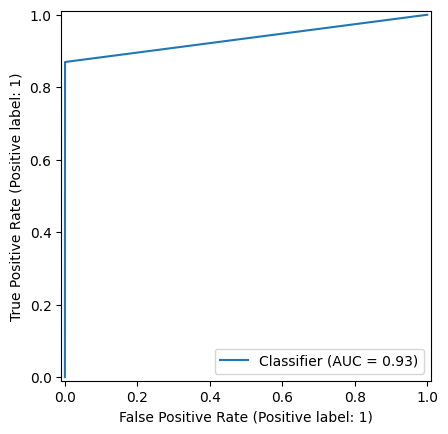

In [16]:
#treino final
model_xb.fit(X_tr, y_tr)

# teste na base de validação
y_pred2 = model_xb.predict(X_val)
y_proba2 = model_xb.predict_proba(X_val)[:,1]



print(f'pr_auc: {average_precision_score(y_val, y_proba2):.2f}\n')
print(f'roc_auc: {roc_auc_score(y_val, y_proba2):.2f}\n')
print(f'Relatório de classificação:\n {classification_report(y_val, y_pred2)}\n')
print(RocCurveDisplay.from_predictions(y_val, y_pred2))
plt.show()

#### é possível que com as técnicas de estratificação das bases com a variável resposta ('stratify base y'), dando importância para a classe rara e o algoritmo configurado com o parâmetro 'scale pos weight' também importante em bases desbalanceadas, tenham contribuido de forma significativa para os resultados apresentados pelo modelo,

#### precisão de 0.80, com o modelo acertando cerca de 80% dos registros que ele entende como fraude.
#### e recall de 0.87, com cerca de 87% dos casos reais de fraude sendo detectadas pelo algoritmo.

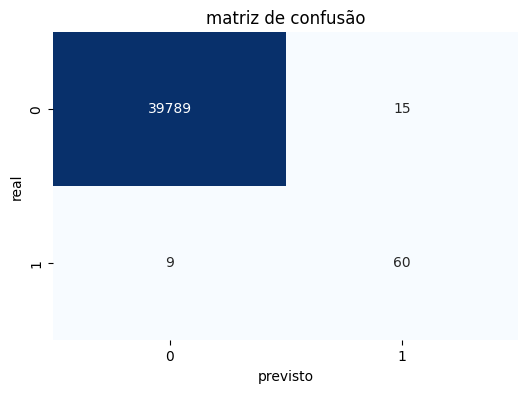

In [17]:
cm2 = confusion_matrix(y_val, y_pred2)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)
plt.title('matriz de confusão')
plt.xlabel('previsto')
plt.ylabel('real')
plt.show()

#### o Xgboost apresentou duas principais melhoras:

#### uma queda de 25% dos falsos negativos em comparação com o baseline e de 60 casos reais, o modelo detectou 60.

#### evolução de 86% na precisão em comparação ao baseline e de 75 registrou que o modelo acusou como fraude, o modelo acertou 60.

#### essa performance está adequada para cenários de fraude, onde a prioridade é não deixar fraude passar.  o status é de um modelo forte e aparentemente generalizando bem.

#### nas próximas etapas será analisada sua performance em dados nãovistos.

## **Tunning do modelo**

#### **Técnica grid search CV**

#### como o modelo já apresentou métricas estáveis, o tunning será feito de forma controlada buscando pequenas melhorias de forma inteligente para evitar overfit no teste.

In [18]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# instanciar o modelo base
model_xb2 = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42
)

params = {
    'n_estimators': randint(100, 400),
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.01, 0.1),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'min_child_weight': randint(1, 6)
}


search = RandomizedSearchCV(
    estimator=model_xb2,
    param_distributions=params,
    cv=cv,
    scoring='average_precision',
    n_iter=20,
    n_jobs=-1,
    random_state=42
)

search.fit(X_tr, y_tr)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....0018A959AAE90>, 'learning_rate': <scipy.stats....0018A959AF010>, 'max_depth': <scipy.stats....0018A958DA790>, 'min_child_weight': <scipy.stats....0018A959B8550>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer 

In [19]:
print((search.best_score_).round(2))
print(search.best_params_)

0.85
{'colsample_bytree': np.float64(0.8400288679743939), 'learning_rate': np.float64(0.09599404067363206), 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 266, 'subsample': np.float64(0.7039794883479599)}


#### modelo permaneceu estável, com score PR_AUC final de 0.85.

#### melhores parâmetros escolhidos: 

**colsample_bytree: 0.84**: o modelo utiliza cerca de 84% das variáveis disponíveis.

**learning_rate de 0.09 e n_estimators de 266:** indica que o modelo melhora a passos pequenos, precisando de um maior número de árvores.

**max_depth de 7:** o modelo viu benefícios em árvores relativamente profundas

**min_child_weight de 1:** o modelo encontrou valor em aprender padrões específicos da fraude.

**subsample de 0.70:** o modelo utiliza cerca de 70% dos registros disponíveis, o que aumenta a robustez.

#### com esse tunning controlado, será analisada sua performance na base de validação, é uma etapa crítica de como o algoritmo se comporta e generaliza, antes do teste final.

In [20]:
model_final = search.best_estimator_

## **Teste inicial do modelo final**

In [21]:
pred3 = model_final.predict(X_val)
proba3 = model_final.predict_proba(X_val)[:, 1]

pr_auc_inicial = average_precision_score(y_val, proba3)
roc_auc_inicial = roc_auc_score(y_val, proba3)

print(f'PR_AUC: {pr_auc_inicial:.2f}')
print(f'ROC_AUC: {roc_auc_inicial:.2f}')
print(f'Relatório de classificação:\n {classification_report(y_val, pred3)}')

PR_AUC: 0.90
ROC_AUC: 0.98
Relatório de classificação:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     39804
           1       0.97      0.84      0.90        69

    accuracy                           1.00     39873
   macro avg       0.98      0.92      0.95     39873
weighted avg       1.00      1.00      1.00     39873



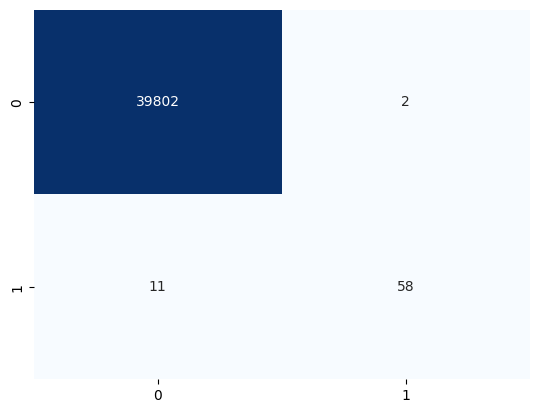

In [22]:
cm3 = confusion_matrix(y_val, pred3)

sns.heatmap(
    cm3,
    annot=True,
    cmap='Blues',
    cbar=False,
    fmt='d'
)

plt.show()

#### o modelo final trocou perder um pouco de recall para ganhar uma excelente precisão. com apenas 2 falsos positivos, o modelo acertou 58 de 60 registros que ele detectou como fraude.

#### o modelo deixou passar 11 casos reais de fraude e apresentou recall de 84%.

#### nesse cenário de fraude, onde se prioriza um modelo agressivo anti fraude, será feito ajuste do limiar (threshold) em busca de uma melhor performance de recall, sem destruir a performance alcançada de precision, pois o modelo dá sinais de boa generalização.

### **Análise de ajustes no threshold**

In [23]:
# criando uma lista com os cortes que queremos testar
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

# 3. O Loop de busca
relatorio_threshold = []

for t in thresholds:
    # Se a proba for maior que o corte, vira 1, senão 0
    predicao = (proba3 >= t).astype(int)
    
    # calculando as métricas para este corte específico
    p = precision_score(y_val, predicao)
    r = recall_score(y_val, predicao)
    f1 = f1_score(y_val, predicao)
    
    relatorio_threshold.append({
        'threshold': t,
        'precision': p,
        'recall': r,
        'f1_score': f1
    })

# 4. Transformamos em DataFrame para análise visual
df_busca = pd.DataFrame(relatorio_threshold)
display(df_busca)

,threshold,precision,recall,f1_score
0,0.2,0.951613,0.855072,0.900763
1,0.3,0.951613,0.855072,0.900763
2,0.4,0.950820,0.840580,0.892308
3,0.5,0.966667,0.840580,0.899225
4,0.6,0.966667,0.840580,0.899225
5,0.7,0.966102,0.826087,0.890625


#### O ajuste de threshold apresentou ganhos marginais em recall, com pequena redução na precisão. Como o modelo já apresentava alta estabilidade e excelente equilíbrio entre falsos positivos e falsos negativos no threshold padrão, optou-se por manter o valor padrão de 0.5 visando maior robustez e generalização no conjunto de teste.

### **Análise das feature importances**

,variaveis,importancia
14,V14,0.423413
10,V10,0.195363
4,V4,0.062496
17,V17,0.031846
20,V20,0.027498


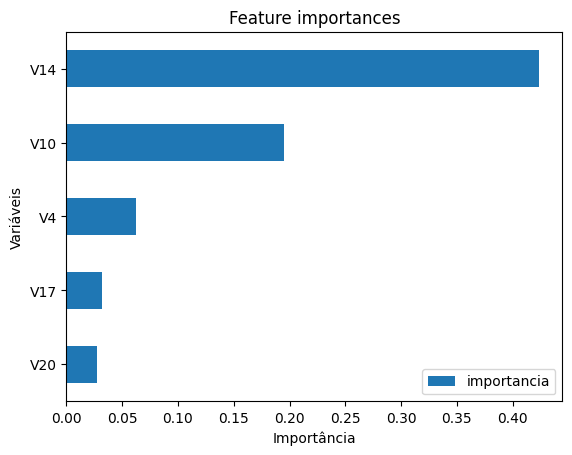

In [24]:
importancia = model_final.feature_importances_

feature_importances = {
    'variaveis': X_tr.columns,
    'importancia': importancia
}

tb_modelo = pd.DataFrame(feature_importances)
display(tb_modelo.sort_values(by='importancia', ascending=False).nlargest(5, columns='importancia'))

tb_modelo.sort_values(by='importancia', ascending=False).head(5).plot(
    kind='barh',
    x='variaveis',
    y='importancia'
)

plt.title('Feature Importances')
plt.xlabel('Importância')
plt.ylabel('Variáveis')

plt.gca().invert_yaxis()

plt.title("Feature importances")
plt.ylabel('Variáveis')

plt.savefig('../imagens/f_importances.png')
plt.show()

In [25]:
linear_corr=linear_corr.reset_index()
tb_comparacao = pd.merge(tb_modelo, linear_corr, left_on='variaveis', right_on='index', how='left')
tb_comparacao = tb_comparacao.rename(columns={'Class': 'correlacao_inicial'})

print('comparação modelo final com correlação inicial:')

display(tb_comparacao[['variaveis', 'importancia', 'correlacao_inicial']].nlargest(5, columns='importancia'))

comparação modelo final com correlação inicial:


,variaveis,importancia,correlacao_inicial
14,V14,0.423413,-0.302544
10,V10,0.195363,-0.216883
4,V4,0.062496,0.133447
17,V17,0.031846,-0.326481
20,V20,0.027498,0.020090


#### Por ser uma base que sofreu a técnica PCA, analisar feature importance ajuda, embora haja limitações de interpretação, pois cada variável é uma combinação matemática de várias variáveis originais.

#### mas nota-se que o modelo é moderadamente dependente de poucas features - variável V14 com importância de 0.42, é mais que as 4 próximas variáveis juntas.

#### contudo, o modelo se mostrou consistente entre a correlação linear inicial e a feature importances

#### e embora V17 apresentasse uma das maiores correlações lineares com a variável alvo, sua importância no XGBoost foi relativamente menor. Isso sugere que parte do sinal preditivo capturado por V17 já estava representado em outros componentes, especialmente V14, reduzindo sua contribuição incremental no modelo.

## **Análise local das previsões do modelo**

### **Técnica SHAP Values**

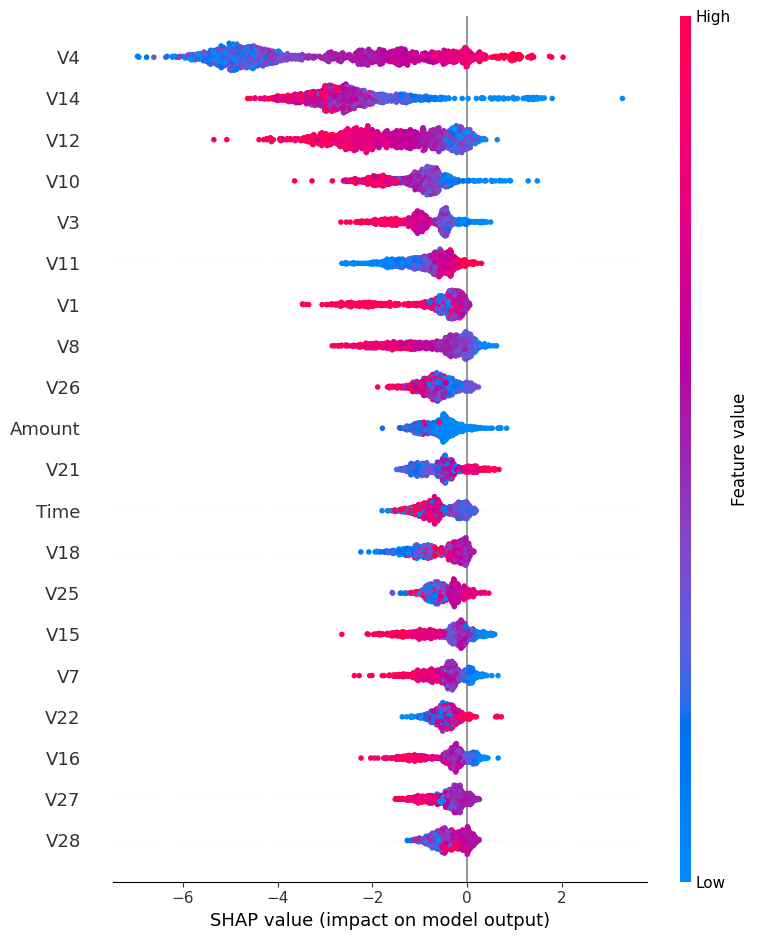

<Figure size 640x480 with 0 Axes>

In [ ]:
import shap

# explicando como o modelo toma decisões
explainer = shap.Explainer(model_final)

# calculando quanto cada variável influenciou, usando uma amostra dos dados
amostra = X_val.sample(1000, random_state=42)

shap_values = explainer(amostra)

# análise visual
shap.summary_plot(shap_values, amostra)

#plt.savefig('../imagens/shap.png')
plt.show()

#### na análise local com shap values, a variável V4 aparece no topo de importância, enquanto na correlação linear inicial ela apareceu inversamente moderada e nas feature importances ela apareceu relativamente fraca, indicando que na prática, a variável V4 influenciou muito as previsões do modelo, participando fortemente de interações.

#### V4 talvez não seja a variável mais usada nas árvores, mas exerce forte influência prática sobre as decisões do modelo.

#### Após essas análises, será visto a performance do modelo final nos dados de testes ainda não vistos

## **Teste final**

In [27]:
# previsões 
y_pred4 = model_final.predict(X_test)

#probabilidade das previsões da classe positiva
y_proba4 = model_final.predict_proba(X_test)[:,1]

pr_auc_final = average_precision_score(y_test, y_proba4)
roc_auc_final = roc_auc_score(y_test, y_proba4)

print(f'PR_AUC: {pr_auc_final:.2f}')
print(f'ROC_AUC: {roc_auc_final:.2f}')
print(f'Relatório de classificação:\n {classification_report(y_test, y_pred4)}')

PR_AUC: 0.84
ROC_AUC: 0.97
Relatório de classificação:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.90      0.77      0.83       148

    accuracy                           1.00     85443
   macro avg       0.95      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



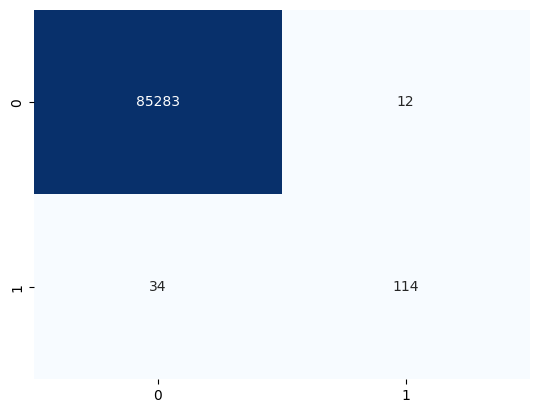

In [28]:
cm4 = confusion_matrix(y_test, y_pred4)

tb_cm4 = pd.DataFrame(cm4)

fn_final = tb_cm4.loc[1, 0]
fp_final = tb_cm4.loc[0, 1]

sns.heatmap(
    cm4,
    annot=True,
    cmap='Blues',
    cbar=False,
    fmt='d'
)

plt.show()

In [29]:
relatorio_final = pd.DataFrame({
    'modelo': ['Árvore de decisão - baseline', 'Xgboost - baseline ', 'Xgboost - final'],
    'metrica pr_auc': [pr_auc_baseline, 0.87, pr_auc_final],
    'metrica roc_auc': [roc_auc_baseline, 0.99, roc_auc_final],
    'qtde FN (falsos negativos)': [fn_baseline, 9, fn_final],
    'qtde FP (falsos positivos)': [fp_baseline, 15, fp_final]
})

relatorio_final['metrica pr_auc'] = relatorio_final['metrica pr_auc'].round(2)
relatorio_final['metrica roc_auc'] = relatorio_final['metrica roc_auc'].round(2)


evolucao = pd.DataFrame()
evolucao['modelo'] = relatorio_final['modelo']
evolucao['diferenca % pr_auc'] = relatorio_final['metrica pr_auc'].pct_change().mul(100).fillna(0).round(1)
evolucao['diferenca % roc_auc'] = relatorio_final['metrica roc_auc'].pct_change().mul(100).fillna(0).round(1)
evolucao['diferenca % FN'] = relatorio_final['qtde FN (falsos negativos)'].pct_change().mul(100).fillna(0).round(1)
evolucao['diferenca % FP'] = relatorio_final['qtde FP (falsos positivos)'].pct_change().mul(100).fillna(0).round(1)


display(relatorio_final)
display(evolucao)


,modelo,metrica pr_auc,metrica roc_auc,qtde FN (falsos negativos),qtde FP (falsos positivos)
0,Árvore de decisão - baseline,0.54,0.91,12,111
1,Xgboost - baseline,0.87,0.99,9,15
2,Xgboost - final,0.84,0.97,34,12


,modelo,diferenca % pr_auc,diferenca % roc_auc,diferenca % FN,diferenca % FP
0,Árvore de decisão - baseline,0.0,0.0,0.0,0.0
1,Xgboost - baseline,61.1,8.8,-25.0,-86.5
2,Xgboost - final,-3.4,-2.0,277.8,-20.0


#### O modelo final foi capaz de melhorar todas as métricas, com excessão apenas da métrica recall, que aumentou de 12 para 34 registros de falsos negativos, ou seja, houve sinal de perda de generalização na métrica recall da classe minoritária. É um resultado esperado por duas hipóteses:
+ **a quantidade de registros fraudulentos mais que dobrou na base de teste e isso importa, pois pequenas mudanças absolutas impactam muito o recall.**
+ **o modelo trocou perder alguns falsos negativos em busca de uma excelente precisão, que caiu de 111 para apenas 12 registros de falsos positivos.**
+ **o Xgboost está conservador e criterioso, mantendo excelente precisão e acusando fraude apenas quando muito confiante.**

#### melhoras do modelo final:
+ **PR_AUC de 0.54 inicial para 0.83, indica que, mesmo tentando buscar os casos raríssimos de fraude, o modelo raramente perde precisão, acusando transações erradas.**
+ **ROC_AUC de 0.97, indica a robustez do modelo em separar bem as classes**
+ **Falsos positivos, apresentou a evolução mais importante do modelo com uma queda significativa dos erros, apresentando precisão de 90%.**

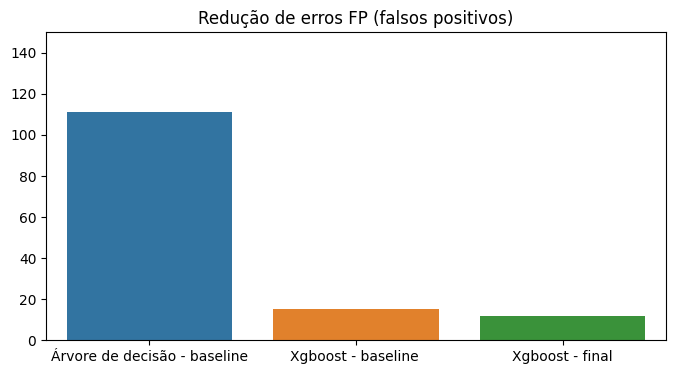

In [30]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=relatorio_final, 
    x='modelo', 
    y='qtde FP (falsos positivos)',
    hue='modelo'
)
plt.title('Redução de erros FP (falsos positivos)')
plt.xlabel('')
plt.ylabel('')
plt.ylim(0, 150)
#plt.savefig('../imagens/fp_modelo')
plt.show()

## **Conclusões**

#### O modelo final apresentou alta precisão (90%), indicando forte capacidade de evitar bloqueios indevidos, ao mesmo tempo em que manteve recall satisfatório na identificação de fraudes reais.

#### em outras palavras, o tuning tornou o modelo mais conservador, reduzindo falsos positivos e elevando precision, porém com leve perda de recall.

### **Limitações e próximos passos**

+ PCA reduz interpretabilidade
+ threshold depende do negócio
+ possível drift em produção

#### **melhorias:**

+ calibração probabilística
+ monitoramento
+ ensemble
+ dados temporais